<a href="https://colab.research.google.com/github/xwang335/Campbell-A/blob/main/summaryRet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


/tmp/ipykernel_4451/423934888.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  port_ret = panel.groupby(['date', 'decile']).apply(weighted_mean).unstack('decile')
/tmp/ipykernel_4451/423934888.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  port_ret = panel.groupby(['date', 'decile']).apply(weighted_mean).unstack('decile')
/tmp/ipykernel_4451/423934888.py:54: DeprecationWarning: DataFrameGroupBy.ap

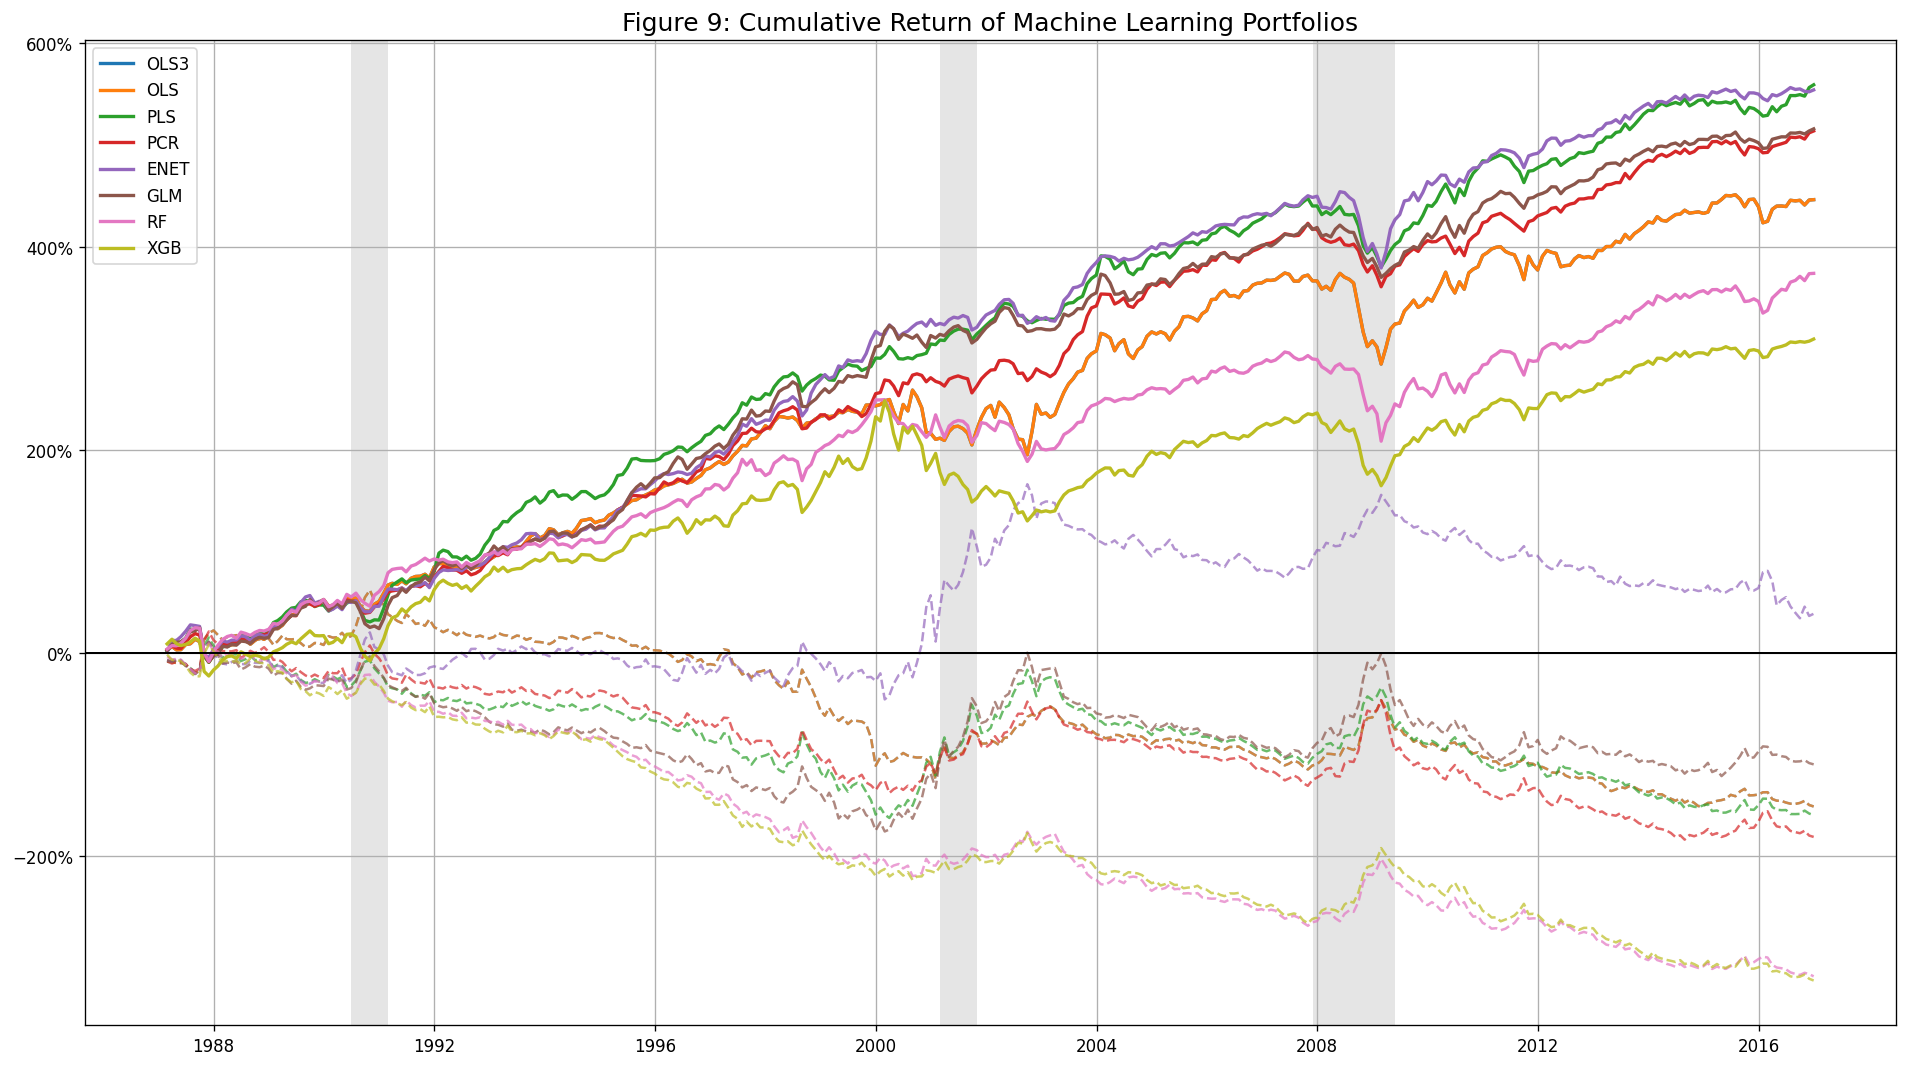

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

import pandas as pd
from google.colab import drive

# 1. 挂载 Google Drive 以获取访问权限
drive.mount('/content/drive/')

# 基础配置
MODELS = ['ols3', 'ols', 'pls', 'pcr', 'enet', 'glm', 'rf', 'xgb']
WEIGHTING = 'value'  # 或 'equal'
OUTPUT_DIR = "/content/drive/MyDrive/Campbell A data/Outputs"



if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

def get_model_returns(file_base, weighting):
    """
    读取模型文件并计算 Decile 1 (Short) 和 Decile 10 (Long) 的累计收益
    """
    # 加载基础数据和预测数据
    temp1 = pd.read_parquet("/content/drive/MyDrive/Campbell A data/crsp_monthly.parquet")
    # 假设文件名格式如提示要求：xxx_predictions.parquet
    temp2 = pd.read_parquet(f"/content/drive/MyDrive/Campbell A data/{file_base}_predictions.parquet")

    temp1['date_m'] = pd.to_datetime(temp1['date']).dt.to_period('M')
    temp2['date_m'] = pd.to_datetime(temp2['DATE']).dt.to_period('M')

    panel = temp1.merge(temp2, on=['permno', 'date_m'], how='inner')

    # 使用原代码中的 assign_decile 逻辑进行分组
    def assign_decile(x):
        if len(x) < 10: return pd.Series(index=x.index, data=np.nan)
        return pd.qcut(x.rank(method='first'), 10, labels=False) + 1

    panel['decile'] = panel.groupby('date')['y_pred'].transform(assign_decile)

    # 计算收益
    if weighting == "value":
        panel = panel.sort_values(['permno', 'date'])
        panel['me_lag'] = panel.groupby('permno')['me'].shift(1)
        panel = panel.dropna(subset=['me_lag'])

        # 加权平均收益
        def weighted_mean(x):
            return np.sum(x['ret'] * x['me_lag']) / np.sum(x['me_lag'])

        port_ret = panel.groupby(['date', 'decile']).apply(weighted_mean).unstack('decile')
    else:
        port_ret = panel.groupby(['date', 'decile'])['ret'].mean().unstack('decile')

    # 提取多头(10)和空头(1)的算术累计收益
    # 注意：空头在图中通常展示为负值或镜像，此处按图中 labels 逻辑处理
    res = pd.DataFrame(index=port_ret.index)
    res['Long'] = port_ret[10].cumsum()
    res['Short'] = port_ret[1].cumsum()

    return res

def plot_all_models(model_list, weighting):
    plt.figure(figsize=(16, 9), dpi=120)
    ax = plt.gca()

    # 1. 硬编码 NBER 衰退期阴影 (Peak to Trough)
    recessions = [
        ('1990-07-01', '1991-03-01'),
        ('2001-03-01', '2001-11-01'),
        ('2007-12-01', '2009-06-01')
    ]
    for start, end in recessions:
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), color='silver', alpha=0.4, lw=0)

    # 2. 高区分度调色板 (Tableau 10)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
              '#8c564b', '#e377c2', '#bcbd22', '#17becf', '#000000']

    # 3. 循环绘图
    for i, model in enumerate(model_list):
        rets = get_model_returns(model, weighting) # 调用之前定义的获取数据函数
        c = colors[i % len(colors)]

        # 实线 = 多头 (Decile 10)
        ax.plot(rets.index, rets['Long'], label=model.upper(), color=c, lw=2.0)
        # 虚线 = 空头 (Decile 1)，取负值镜像到 0 轴下方
        ax.plot(rets.index, -rets['Short'], color=c, lw=1.5, ls='--', alpha=0.7)

    # 4. 格式美化
    ax.axhline(0, color='black', lw=1.2)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title("Figure 9: Cumulative Return of Machine Learning Portfolios", fontsize=15)

    # 5. 双图例逻辑
    # 模型图例 (左上)
    leg1 = ax.legend(loc='upper left', ncol=5, frameon=False, bbox_to_anchor=(0, 1.1))
    ax.add_artist(leg1)
    # 线型图例 (右上)
    from matplotlib.lines import Line2D
    lines = [Line2D([0], [0], color='black', lw=2), Line2D([0], [0], color='black', lw=1.5, ls='--')]
    ax.legend(lines, ['Long Position', 'Short Position'], loc='upper right')

    plt.tight_layout()
    plt.grid(True)
    plt.legend()
    plt.show()


if __name__ == "__main__":
    plot_all_models(MODELS, WEIGHTING)